In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects  as go
import datetime as dt
from matplotlib import  pyplot
import yfinance as yf
import matplotlib.pyplot as plt

In [17]:
df=yf.Ticker("NQ=F")
df=df.history(period='max')
df=df[df['Volume']!=0]
df.reset_index(inplace=True)
df.drop(['Dividends','Stock Splits'],axis='columns',inplace=True)
df.columns=['date','open','high','low','close','volume']
df

,date,open,high,low,close,volume
0,2000-09-18 00:00:00-04:00,3721.0,3785.500000,3602.00,3653.50,72994
1,2000-09-19 00:00:00-04:00,3658.5,3817.000000,3656.00,3804.00,70029
2,2000-09-20 00:00:00-04:00,3801.5,3874.000000,3715.50,3853.00,78832
3,2000-09-21 00:00:00-04:00,3852.0,3874.000000,3744.00,3765.00,70719
4,2000-09-22 00:00:00-04:00,3673.0,3780.000000,3615.00,3776.00,55926
...,...,...,...,...,...,...
5888,2024-01-17 00:00:00-05:00,16978.0,16982.000000,16689.25,16869.75,722784
5889,2024-01-18 00:00:00-05:00,16854.5,17125.750000,16834.25,17110.00,852229
5890,2024-01-19 00:00:00-05:00,17116.0,17471.250000,17107.25,17438.50,758132
5891,2024-01-22 00:00:00-05:00,17466.0,17585.000000,17434.00,17458.50,758132


In [14]:
def check_trend_line(support: bool, pivot: int, slope: float, y: np.array):
    # compute sum of differences between line and prices, 
    # return negative val if invalid 
    
    # Find the intercept of the line going through pivot point with given slope
    intercept = -slope * pivot + y[pivot]
    line_vals = slope * np.arange(len(y)) + intercept
     
    diffs = line_vals - y
    
    # Check to see if the line is valid, return -1 if it is not valid.
    if support and diffs.max() > 1e-5:
        return -1.0
    elif not support and diffs.min() < -1e-5:
        return -1.0

    # Squared sum of diffs between data and line 
    err = (diffs ** 2.0).sum()
    return err;



In [15]:
def optimize_slope(support: bool, pivot:int , init_slope: float, y: np.array):
    
    # Amount to change slope by. Multiplyed by opt_step
    slope_unit = (y.max() - y.min()) / len(y) 
    
    # Optmization variables
    opt_step = 1.0
    min_step = 0.0001
    curr_step = opt_step # current step
    
    # Initiate at the slope of the line of best fit
    best_slope = init_slope
    best_err = check_trend_line(support, pivot, init_slope, y)
    assert(best_err >= 0.0) # Shouldn't ever fail with initial slope

    get_derivative = True
    derivative = None
    while curr_step > min_step:

        if get_derivative:
            # Numerical differentiation, increase slope by very small amount
            # to see if error increases/decreases. 
            # Gives us the direction to change slope.
            slope_change = best_slope + slope_unit * min_step
            test_err = check_trend_line(support, pivot, slope_change, y)
            derivative = test_err - best_err;
            
            # If increasing by a small amount fails, 
            # try decreasing by a small amount
            if test_err < 0.0:
                slope_change = best_slope - slope_unit * min_step
                test_err = check_trend_line(support, pivot, slope_change, y)
                derivative = best_err - test_err

            if test_err < 0.0: # Derivative failed, give up
                raise Exception("Derivative failed. Check your data. ")

            get_derivative = False

        if derivative > 0.0: # Increasing slope increased error
            test_slope = best_slope - slope_unit * curr_step
        else: # Increasing slope decreased error
            test_slope = best_slope + slope_unit * curr_step
        

        test_err = check_trend_line(support, pivot, test_slope, y)
        if test_err < 0 or test_err >= best_err: 
            # slope failed/didn't reduce error
            curr_step *= 0.5 # Reduce step size
        else: # test slope reduced error
            best_err = test_err 
            best_slope = test_slope
            get_derivative = True # Recompute derivative
    
    # Optimize done, return best slope and intercept
    return (best_slope, -best_slope * pivot + y[pivot])

In [16]:
def fit_upper_trendline(data: np.array):
    x = np.arange(len(data))
    coefs = np.polyfit(x, data, 1)
    line_points = coefs[0] * x + coefs[1]
    upper_pivot = (data - line_points).argmax() 
    resist_coefs = optimize_slope(False, upper_pivot, coefs[0], data)
    return resist_coefs 

def fit_lower_trendline(data: np.array):
    x = np.arange(len(data))
    coefs = np.polyfit(x, data, 1)
    line_points = coefs[0] * x + coefs[1]
    lower_pivot = (data - line_points).argmin() 
    support_coefs = optimize_slope(True, lower_pivot, coefs[0], data)
    return support_coefs 

In [17]:
def fit_trendlines_single(data: np.array):
    # find line of best fit (least squared) 
    # coefs[0] = slope,  coefs[1] = intercept 
    x = np.arange(len(data))
    coefs = np.polyfit(x, data, 1)

    # Get points of line.
    line_points = coefs[0] * x + coefs[1]

    # Find upper and lower pivot points
    upper_pivot = (data - line_points).argmax() 
    lower_pivot = (data - line_points).argmin() 
   
    # Optimize the slope for both trend lines
    support_coefs = optimize_slope(True, lower_pivot, coefs[0], data)
    resist_coefs = optimize_slope(False, upper_pivot, coefs[0], data)

    return (support_coefs, resist_coefs) 

In [18]:
def fit_trendlines_high_low(high: np.array, low: np.array, close: np.array):
    x = np.arange(len(close))
    coefs = np.polyfit(x, close, 1)
    # coefs[0] = slope,  coefs[1] = intercept
    line_points = coefs[0] * x + coefs[1]
    upper_pivot = (high - line_points).argmax() 
    lower_pivot = (low - line_points).argmin() 
    
    support_coefs = optimize_slope(True, lower_pivot, coefs[0], low)
    resist_coefs = optimize_slope(False, upper_pivot, coefs[0], high)

    return (support_coefs, resist_coefs)

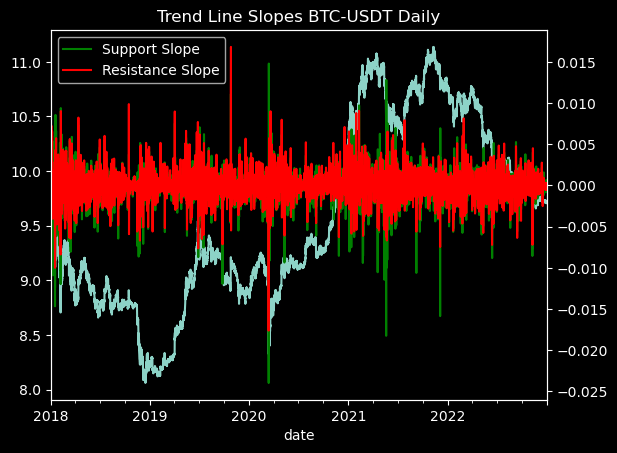

In [14]:
if __name__ == '__main__':

    # Load data
    data=pd.read_csv('BTCUSDT3600.csv')
    data['date'] = data['date'].astype('datetime64[s]')
    data = data.set_index('date')

    # Take natural log of data to resolve price scaling issues
    data = np.log(data)
    # Trendline parameter
    lookback = 30


    support_slope = [np.nan] * len(data)
    resist_slope = [np.nan] * len(data)
    for i in range(lookback - 1, len(data)):
        candles = data.iloc[i - lookback + 1: i + 1]
        support_coefs, resist_coefs =  fit_trendlines_high_low(candles['high'], 
                                                               candles['low'], 
                                                               candles['close'])
        support_slope[i] = support_coefs[0]
        resist_slope[i] = resist_coefs[0]

    data['support_slope'] = support_slope
    data['resist_slope'] = resist_slope

    plt.style.use('dark_background')
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    data['close'].plot(ax=ax1)
    data['support_slope'].plot(ax=ax2, label='Support Slope', color='green')
    data['resist_slope'].plot(ax=ax2, label='Resistance Slope', color='red')
    plt.title("Trend Line Slopes BTC-USDT Daily")
    plt.legend()
    plt.show()

In [34]:
data=data.reset_index()
data

,date,open,high,low,close,volume
0,2018-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,2018-01-01 01:00:00,13527.841167,13595.259915,13153.294540,13203.699294,384.940892
2,2018-01-01 02:00:00,13203.567250,13419.331793,13199.152380,13331.250914,429.888403
3,2018-01-01 03:00:00,13332.298878,13612.086569,13288.738587,13408.246493,421.922265
4,2018-01-01 04:00:00,13432.589137,13621.198504,13318.180709,13596.151799,342.690926
...,...,...,...,...,...,...
43819,2022-12-31 19:00:00,16577.716287,16589.996745,16565.164171,16570.118457,4139.299329
43820,2022-12-31 20:00:00,16570.120747,16574.925554,16564.125024,16568.597952,2676.973597
43821,2022-12-31 21:00:00,16568.194476,16571.613435,16544.177461,16548.288951,3671.785129
43822,2022-12-31 22:00:00,16548.310982,16567.417279,16470.129090,16520.719207,6996.182394


In [36]:
dfpl = data[43500:len(data)]

fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                                     open=dfpl['open'],
                                     high=dfpl['high'],
                                     low=dfpl['low'],
                                     close=dfpl['close'])])

fig.update_layout(title='Candlestick Chart',
                  xaxis_title='Date',
                  yaxis_title='Price')

fig.show()
